In [3]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
import warnings
from sklearn.metrics import r2_score
from sklearn.exceptions import ConvergenceWarning
import tqdm.notebook as tqdm

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot, plot10
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex

native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

...

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/10 [00:00<?, ?it/s]

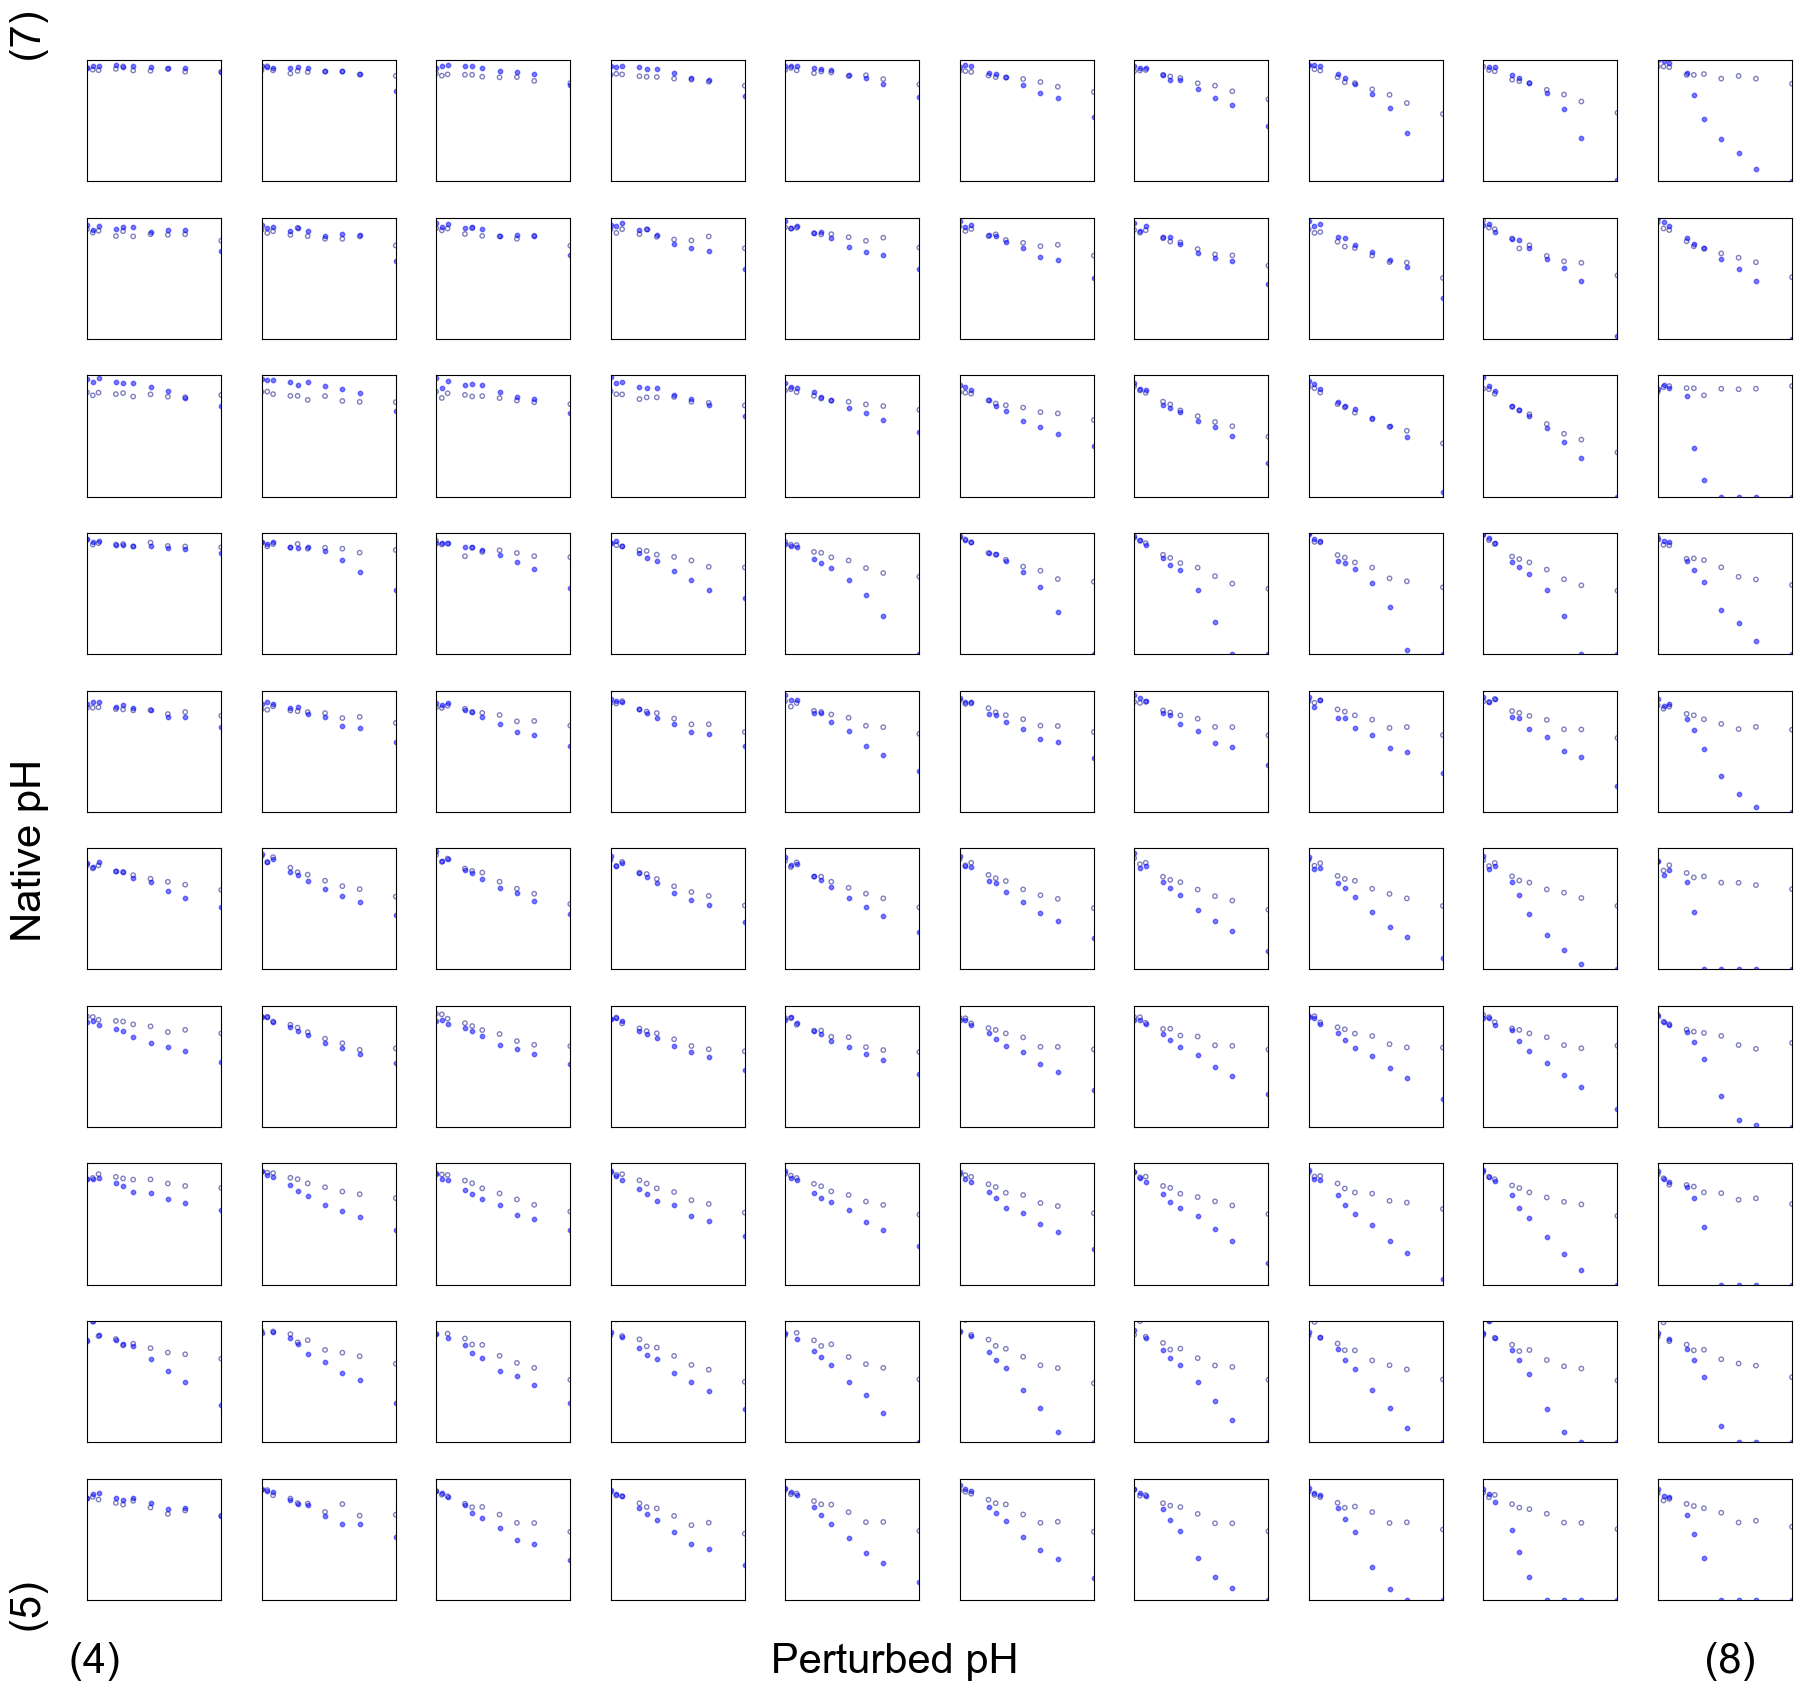

In [ ]:
import tqdm.notebook as tqdm
from mgsa.io import get_ammonia
fig, axs = plt.subplots(10, 10, figsize=(22, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig.supxlabel('(4)                                                        Perturbed pH                                                           (8)', fontname = 'Arial', fontsize=30, y=0.07)
fig.supylabel('(5)                                                     Native pH                                                          (7)', fontname = 'Arial', fontsize=30, x=0.09)


t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
I_0 = 0
K_A = 0.1
K_I = 0.1
K_C = 0.1
dt = 0.05
T = 9
gamma = 5

N = int(T/dt)


indx = [0, 4, 8, 20, 25, 32, 44, 56, 68, 93]
indices = [int(int(9/dt-1)*x/max(indx)) for x in indx]
indices = np.array(indices)
t_scatter = [9*x/93 for x in indx]

for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(10, desc = 'pert'):  

        sample = samples_from_soils(soils[9 - native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
        A_data_drug = A_data_drug/3
        y_data_drug = np.concatenate([A_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
        A_data = A_data/3
        
    
        
        
        ax = axs[native, pert]
        ax.scatter(t_scatter, A_data_drug, color='navy', s=10, facecolors = 'none', alpha = 0.5)
        ax.scatter(t_scatter, A_data, color='Blue', s=10, alpha = 0.5)  
        
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 2.2)
        
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.show()

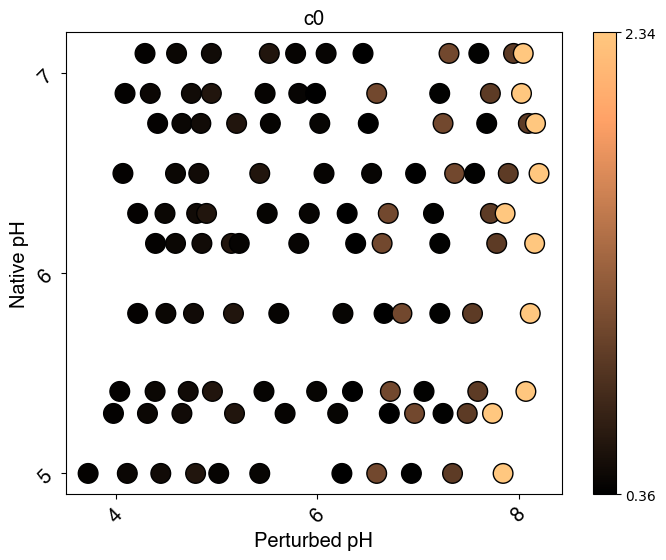

<Axes: title={'center': 'c0'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [5]:
carbon = pd.read_csv('../data/carbon.csv')
c0 = np.zeros((10,11)) #units dM so it is same order of magnitude as A and I

for nat in range(10):
    for pert in range(11):
        soil = soils[native]
        samples = samples_from_soils(soil)
        sample = samples[pert]
        parts = sample.split('_')

        if 'N' in parts[3]:
            unit = int(parts[4]) 
        else:
            unit = int(parts[3])
            
        filtered = carbon[(carbon['Soil'] == soil) & (carbon['Unit'] == unit)]
        c0[nat, pert] = 0.01*filtered['TOC_mM'].sum()/3
        
        
            
plot(c0, 'c0', cmap = 'copper')

In [9]:
def RHS(y, params):
    x, A, C = y
    gamma, K_A, K_C = params

    dx = x*gamma*(A/(K_A + A))*C/(K_C + C)
    dA = -x*A/(K_A + A)
    dC = - x*C/(K_C + C)
    
    dydt = np.array([dx, dA, dC])
    return dydt

$$
\begin{align*}
    \dot{x} &= r_A\gamma\frac{A}{K_A + A}\frac{C}{K_C + C}x\\
    \dot{A} &= - r_A x \frac{A}{K_A + A}\\
    \dot{C} &= - r_A x \frac{C}{K_C + C}
\end{align*}
$$

native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

...

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

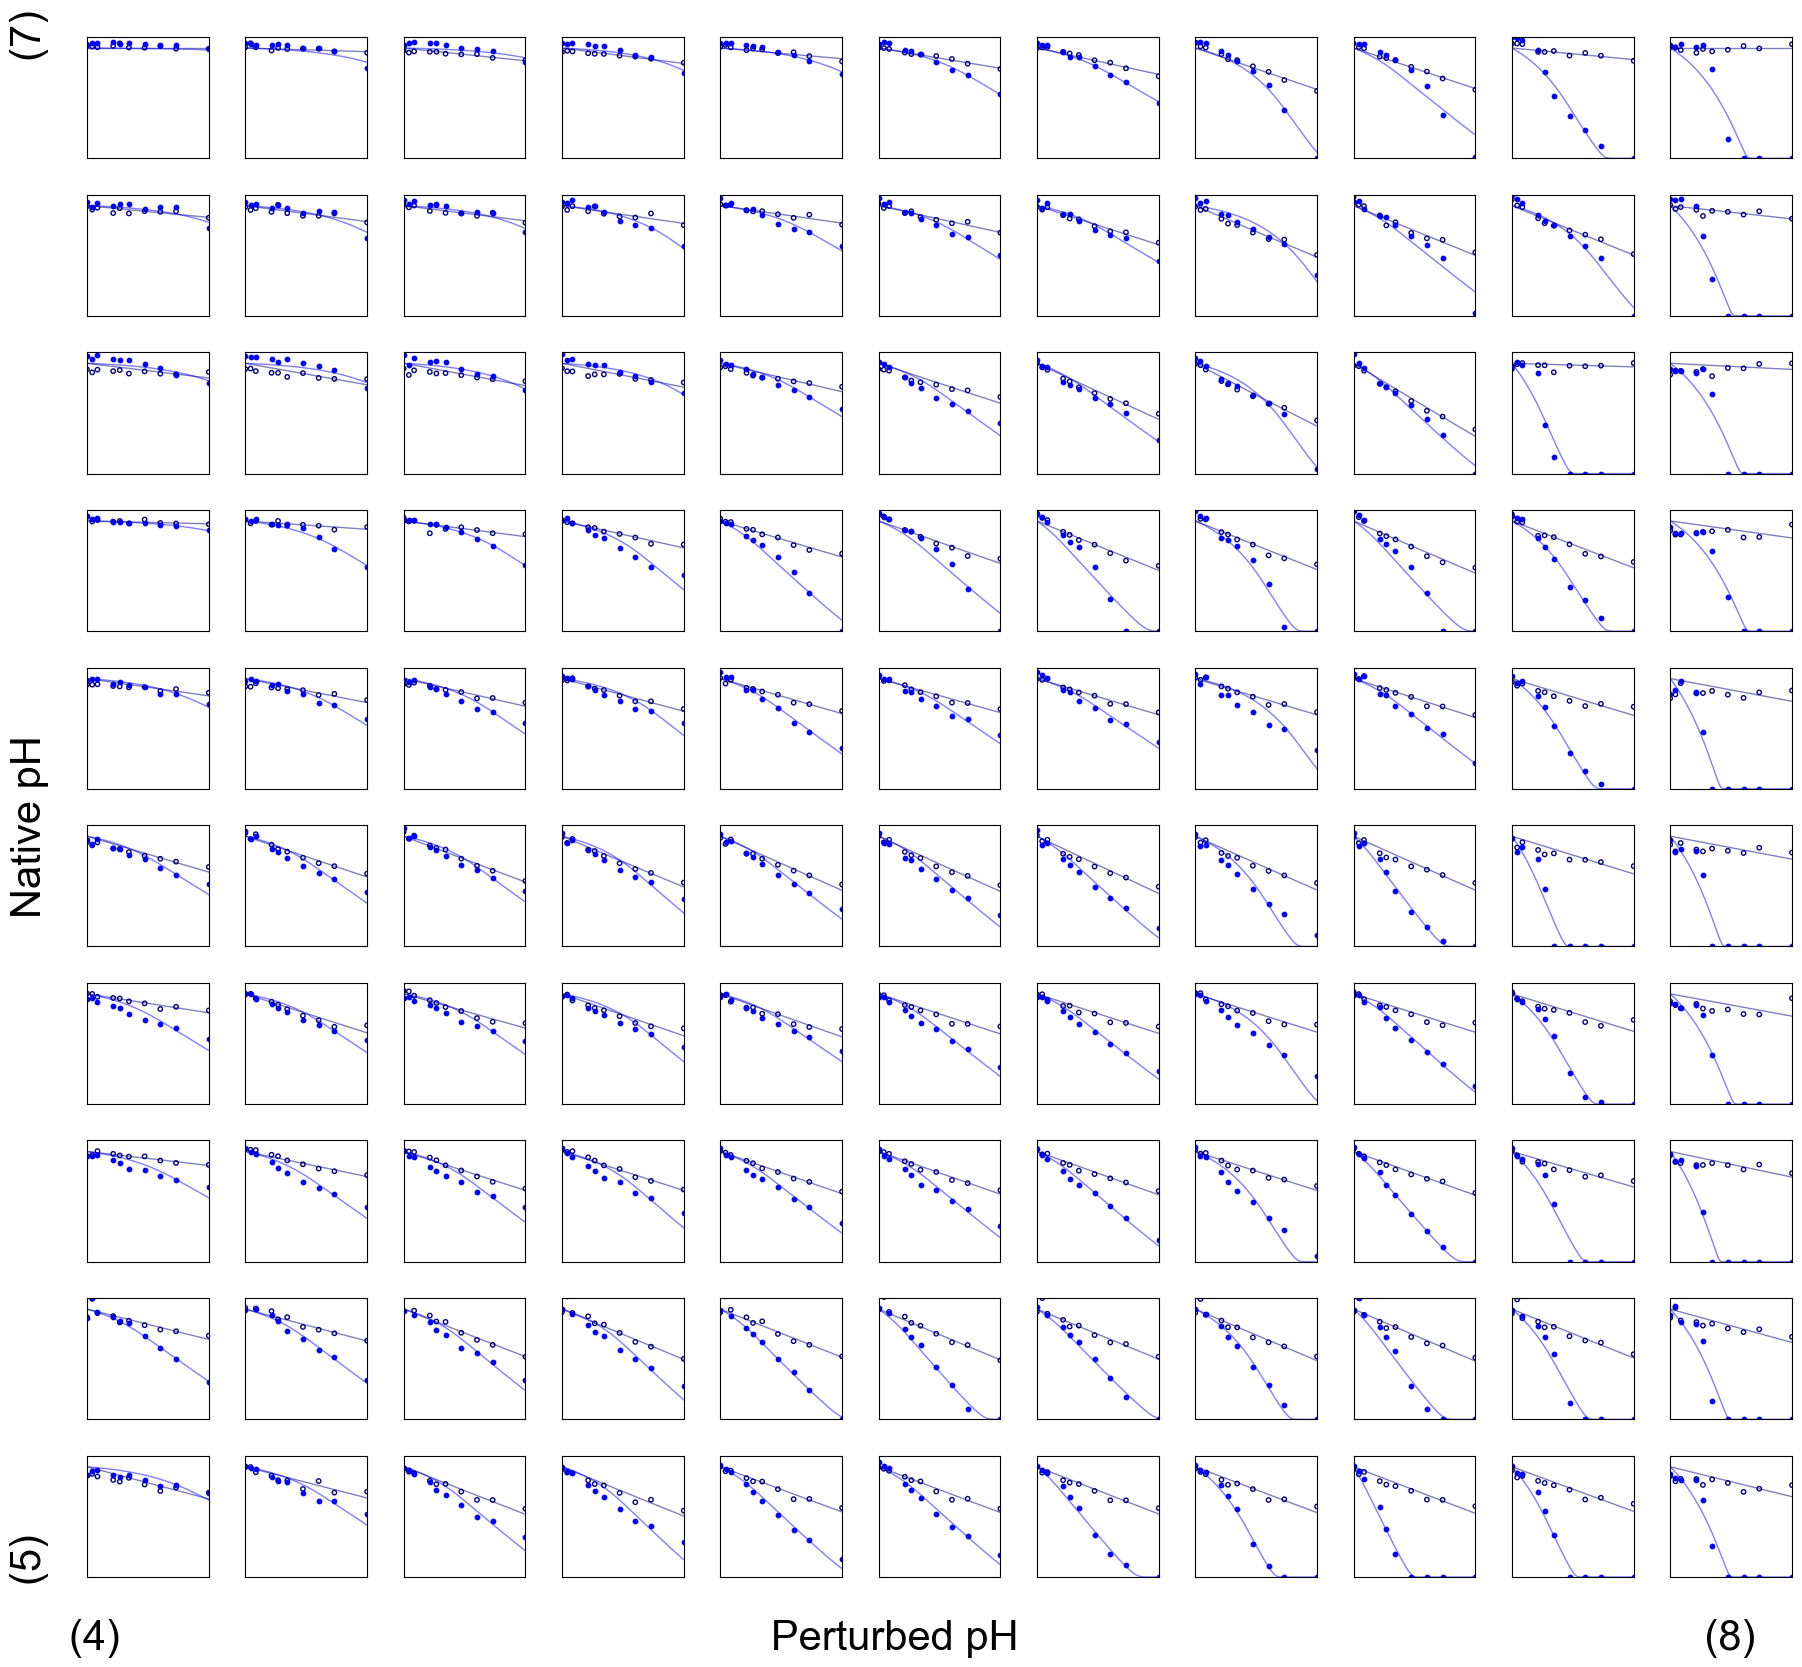

In [38]:
import tqdm.notebook as tqdm
fig, axs = plt.subplots(10, 11, figsize=(22, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
from mgsa.modeling import simulate

fig.supxlabel('(4)                                                        Perturbed pH                                                           (8)', fontname = 'Arial', fontsize=30, y=0.07)
fig.supylabel('(5)                                                     Native pH                                                          (7)', fontname = 'Arial', fontsize=30, x=0.09)


t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
K_A = 0.05
K_C = 0.05
dt = 0.05
T = 9
gamma = 0.3

N = int(T/dt)

indx = [0, 4, 8, 20, 25, 32, 44, 56, 68, 93]
indices = [int(int(9/dt-1)*x/max(indx)) for x in indx]
indices = np.array(indices)
t_scatter = [9*x/93 for x in indx]

param_values = np.zeros((10,11,2))

for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(11, desc = 'pert'):  
        
        C_0 = c0[native, pert]

        sample = samples_from_soils(soils[native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
        A_data_drug = A_data_drug/3
        y_data_drug = np.concatenate([A_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
        A_data = A_data/3
        y_data = np.concatenate([A_data])
        
        
        def model_drug(t, rx_0):

            y0 = np.array([rx_0, A_0, 0])
            params = [0, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        
        initial_guess = [0.1]
        bounds = ([0.00001], [10])
        
        popt, pcov = curve_fit(model_drug, t_data, y_data_drug, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][0] = popt[0]
        x_0 = popt[0]

        y0 = np.array([popt[0], A_0, 0])
        params = [0,  K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[9 - native, pert]
        ax.plot(t, A, color='navy', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data_drug, color='navy', s=10, facecolors = 'none')
        
        def model(t, rx_0):

            y0 = np.array([rx_0, A_0, C_0])
            params = [gamma, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        initial_guess = [0.1]
            
        bounds = ([0.001], [20])
        
        popt, pcov = curve_fit(model, t_data, A_data, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][1] = popt[0]

        y0 = np.array([popt[0], A_0, C_0])
        params = [gamma, K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[9 - native, pert]
        ax.plot(t, A, color='Blue', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data, color='Blue', s=10)
        
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 2.2)
        
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.show()

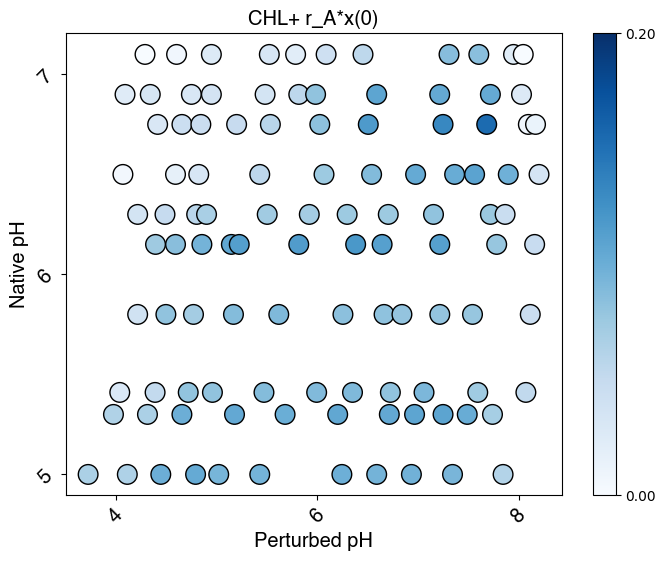

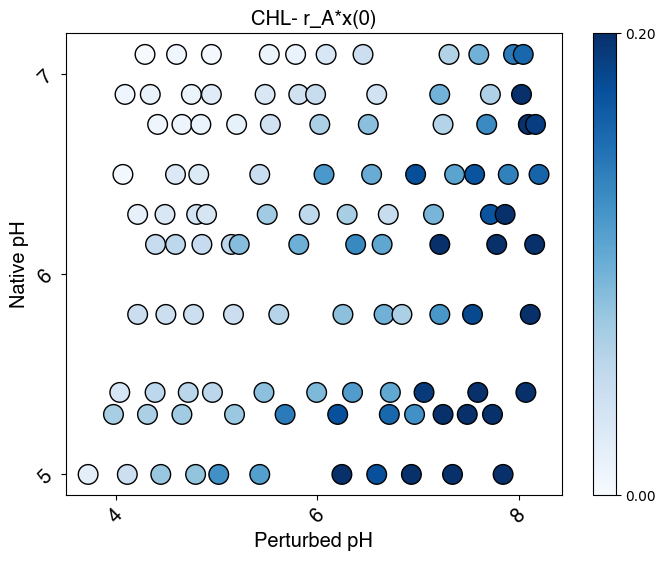

<Axes: title={'center': 'CHL- r_A*x(0)'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [76]:
plot(param_values[:, :, 0], 'CHL+ r_A*x(0)', vmin = 0, vmax = 0.2)
plot(param_values[:, :, 1], 'CHL- r_A*x(0)', vmin = 0, vmax = 0.2)

### Create Scatter Plots

In [87]:
group_1_T0 = pd.read_csv('../out/groups/proteo_groups1_T0.tsv', header = None, sep = '\t').values
group_2_T0 = pd.read_csv('../out/groups/proteo_groups2_T0.tsv', header = None, sep = '\t').values
group_3_T0 = pd.read_csv('../out/groups/proteo_groups3_T0.tsv', header = None, sep = '\t').values
group_1_T9 = pd.read_csv('../out/groups/proteo_groups1_T9.tsv', header = None, sep = '\t').values
group_2_T9 = pd.read_csv('../out/groups/proteo_groups2_T9.tsv', header = None, sep = '\t').values
group_3_T9 = pd.read_csv('../out/groups/proteo_groups3_T9.tsv', header = None, sep = '\t').values

from mgsa.io import pH_soil
pH_matrix = np.zeros((10,11))
for i in range(len(pH_matrix)):
    pH_matrix[i] = pH_soil(soils[i])

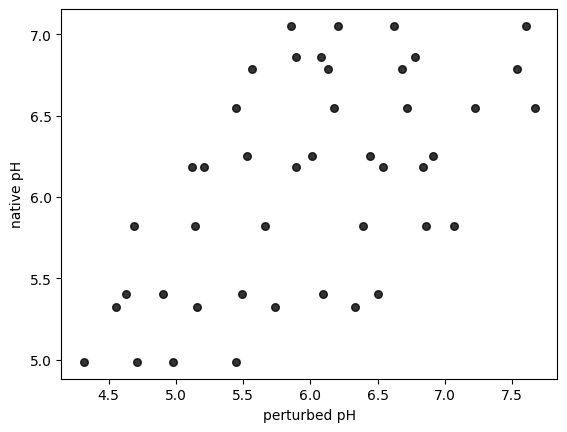

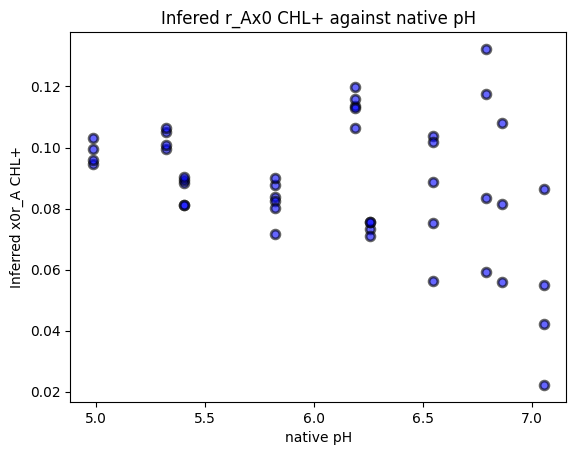

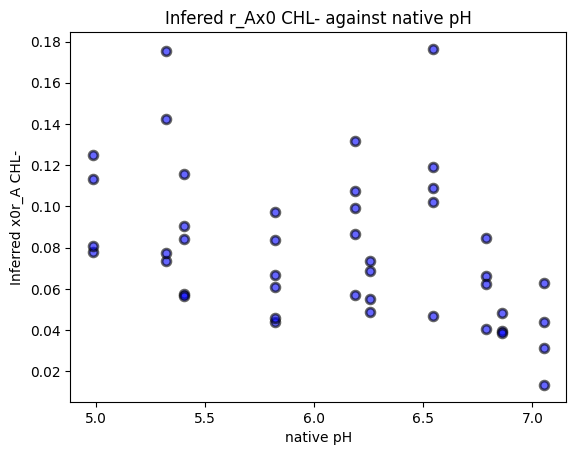

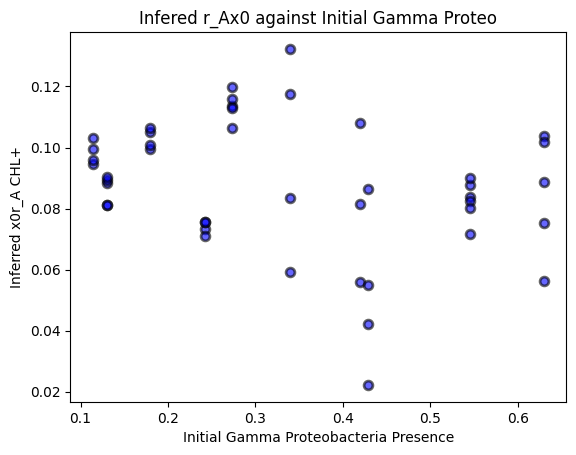

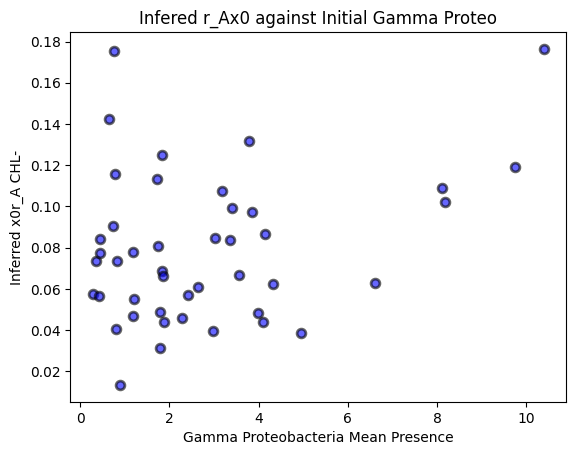

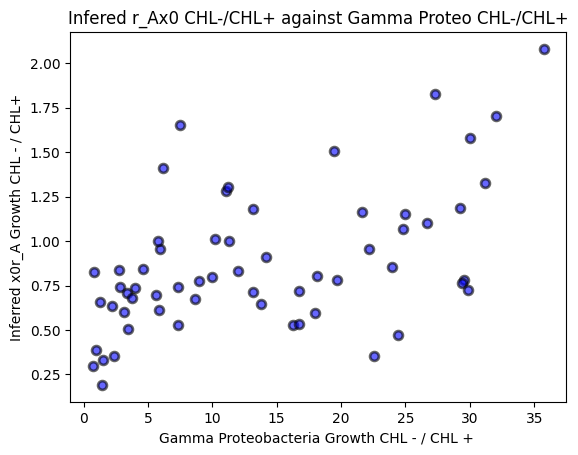

In [101]:
native = [4.987, 5.324, 5.405, 5.822, 6.186, 6.255, 6.545, 6.789, 6.86,  7.052]
thres = 1.25

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(pH_matrix[nat, pert], native[nat], color = 'Black', s=30, alpha = 0.8)
            plt.xlabel('perturbed pH')
            plt.ylabel('native pH')
                
plt.show()
for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(native[nat], param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('native pH')
            plt.ylabel('Inferred x0r_A CHL+')
            plt.title('Infered r_Ax0 CHL+ against native pH')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(native[nat], param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('native pH')
            plt.ylabel('Inferred x0r_A CHL-')
            plt.title('Infered r_Ax0 CHL- against native pH')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(group_1_T0[nat, pert] + group_3_T0[nat, pert], param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Initial Gamma Proteobacteria Presence')
            plt.ylabel('Inferred x0r_A CHL+')
            plt.title('Infered r_Ax0 against Initial Gamma Proteo')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter((group_1_T0[nat, pert] + group_3_T0[nat, pert] + group_1_T9[nat, pert] + group_3_T9[nat, pert])/2, param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Gamma Proteobacteria Mean Presence')
            plt.ylabel('Inferred x0r_A CHL-')
            plt.title('Infered r_Ax0 against Initial Gamma Proteo')
plt.show()

# for nat in range(10):
#     for pert in range(2,8):
#         if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
#             plt.scatter((group_2_T0[nat, pert] + group_2_T9[nat, pert])/2, param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
#             plt.xlabel('Alpha Proteobacteria Mean Presence')
#             plt.ylabel('Inferred x0r_A CHL-')
#             plt.title('Infered r_Ax0 against Initial Gamma Proteo')
# plt.show()

         
for nat in range(10):
    for pert in range(2,8):
        plt.scatter((group_1_T9[nat, pert] + group_3_T9[nat, pert])/(group_1_T0[nat, pert] + group_3_T0[nat, pert]), param_values[nat, pert, 1]/param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
        plt.xlabel('Gamma Proteobacteria Growth CHL - / CHL + ')
        plt.ylabel('Inferred x0r_A Growth CHL - / CHL+')
        plt.title('Infered r_Ax0 CHL-/CHL+ against Gamma Proteo CHL-/CHL+')
plt.show()

### Try another set of parameters 

fix x_0 = 0

fit r_A

In [102]:
def RHS(y, params):
    x, A, C = y
    gamma, r_A, K_A, K_C = params

    dx = x*r_A*gamma*(A/(K_A + A))*C/(K_C + C)
    dA = -x*r_A*A/(K_A + A)
    dC = - x*r_A*C/(K_C + C)
    
    dydt = np.array([dx, dA, dC])
    return dydt

native:   0%|          | 0/10 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

...

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

pert:   0%|          | 0/11 [00:00<?, ?it/s]

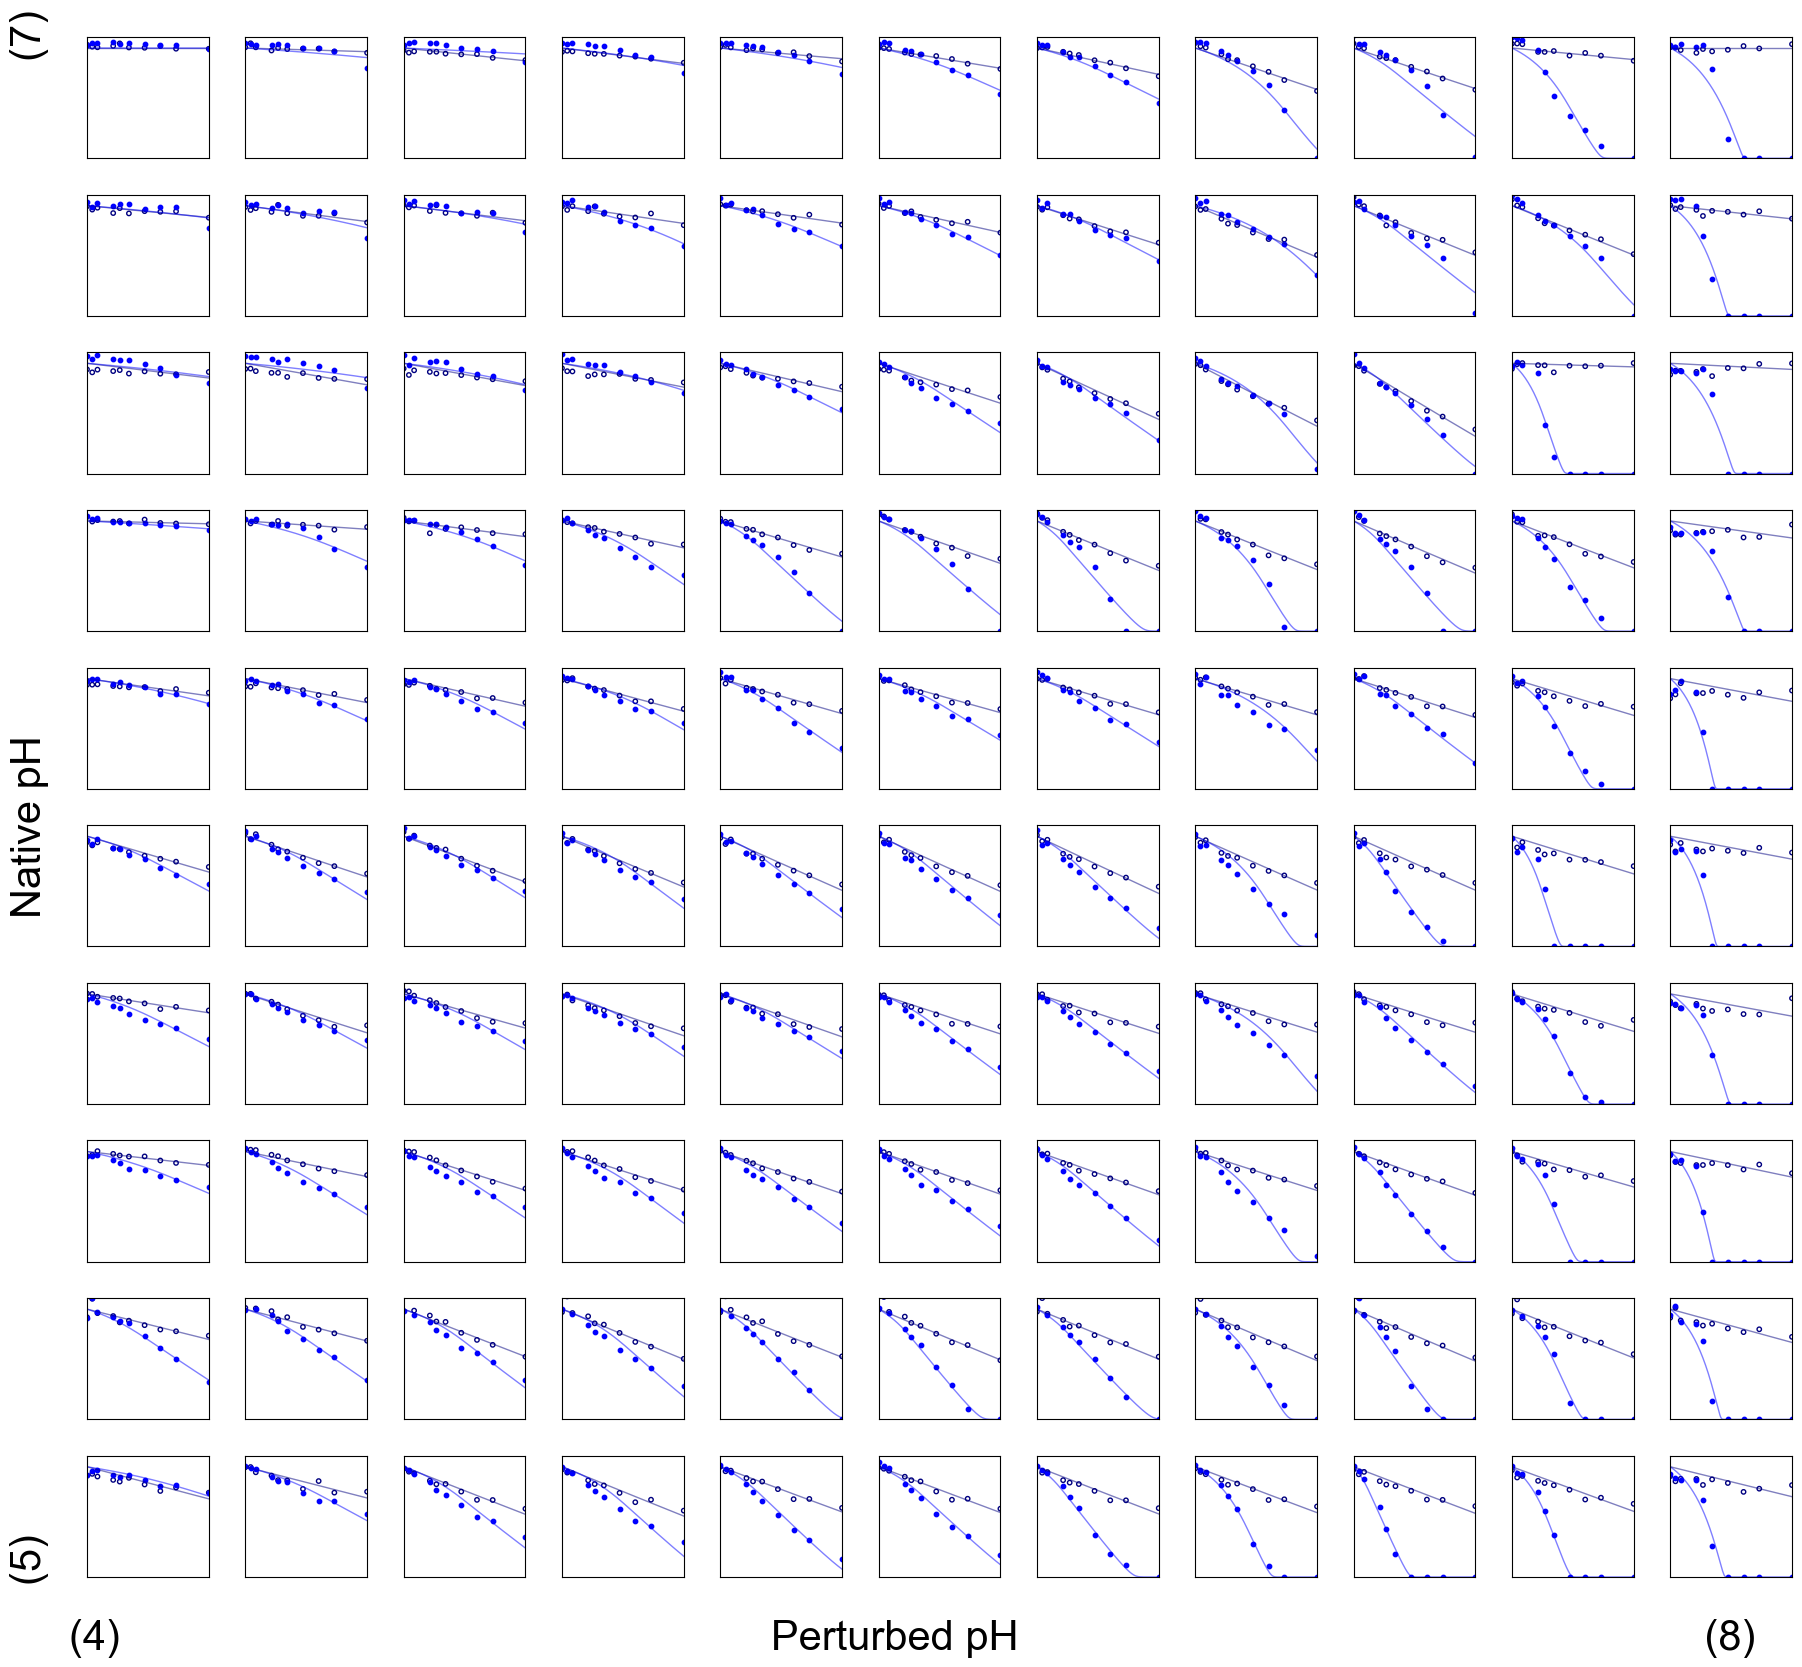

In [126]:
import tqdm.notebook as tqdm
fig, axs = plt.subplots(10, 11, figsize=(22, 20))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
from mgsa.modeling import simulate

fig.supxlabel('(4)                                                        Perturbed pH                                                           (8)', fontname = 'Arial', fontsize=30, y=0.07)
fig.supylabel('(5)                                                     Native pH                                                          (7)', fontname = 'Arial', fontsize=30, x=0.09)


t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
K_A = 0.05
K_C = 0.05
dt = 0.05
T = 9
x_0 = 0.1
gamma = 0.3

N = int(T/dt)

indx = [0, 4, 8, 20, 25, 32, 44, 56, 68, 93]
indices = [int(int(9/dt-1)*x/max(indx)) for x in indx]
indices = np.array(indices)
t_scatter = [9*x/93 for x in indx]

param_values = np.zeros((10,11,2))

for native in tqdm.trange(10, desc = 'native'): 
    for pert in tqdm.trange(11, desc = 'pert'):  
        
        C_0 = c0[native, pert]

        sample = samples_from_soils(soils[native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
        A_data_drug = A_data_drug/3
        y_data_drug = np.concatenate([A_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
        A_data = A_data/3
        y_data = np.concatenate([A_data])
        
        
        def model_drug(t, r_A):

            y0 = np.array([x_0, A_0, 0])
            params = [0, r_A, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        
        initial_guess = [0.1]
        bounds = ([0.00001], [100])
        
        popt, pcov = curve_fit(model_drug, t_data, y_data_drug, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][0] = popt[0]

        y0 = np.array([x_0, A_0, 0])
        params = [0, popt[0],  K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[9 - native, pert]
        ax.plot(t, A, color='navy', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data_drug, color='navy', s=10, facecolors = 'none')
        
        def model(t, r_A):

            y0 = np.array([x_0, A_0, C_0])
            params = [gamma, r_A, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        initial_guess = [0.1]
            
        bounds = ([0.001], [100])
        
        popt, pcov = curve_fit(model, t_data, A_data, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][1] = popt[0]

        y0 = np.array([x_0, A_0, C_0])
        params = [gamma, popt[0], K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[9 - native, pert]
        ax.plot(t, A, color='Blue', alpha=0.5, linewidth=1)
        ax.scatter(t_scatter, A_data, color='Blue', s=10)
        
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 2.2)
        
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.show()

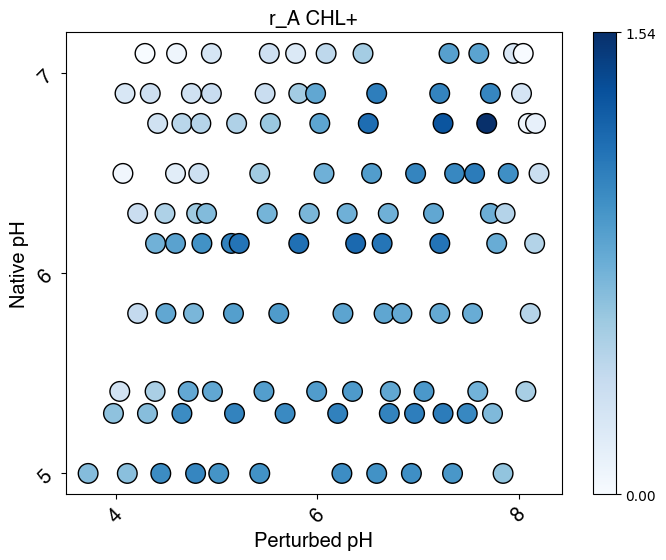

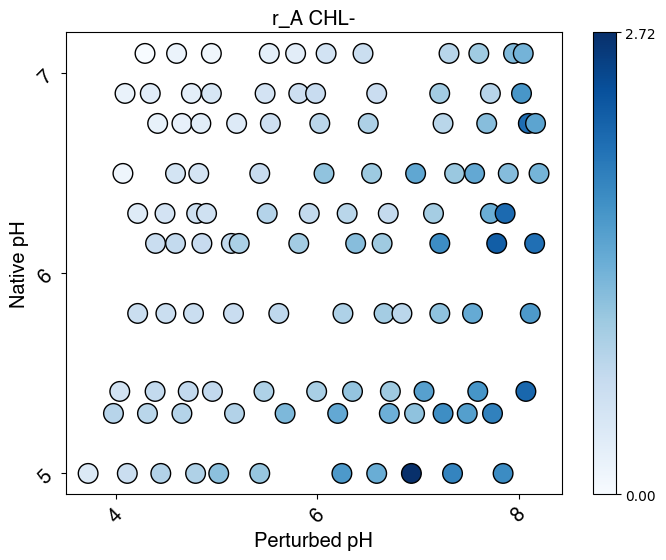

<Axes: title={'center': 'r_A CHL-'}, xlabel='Perturbed pH', ylabel='Native pH'>

In [107]:
plot(param_values[:,:,0], 'r_A CHL+')
plot(param_values[:,:,1], 'r_A CHL-')

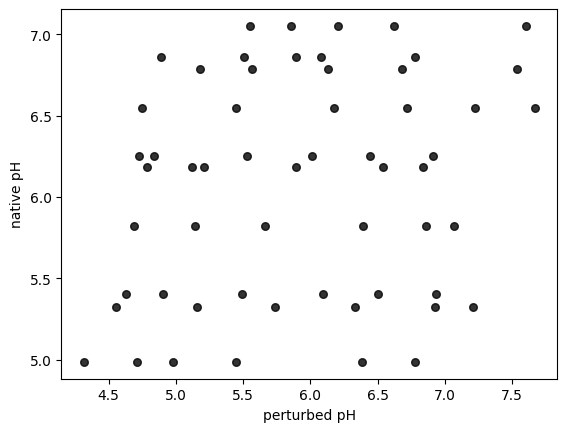

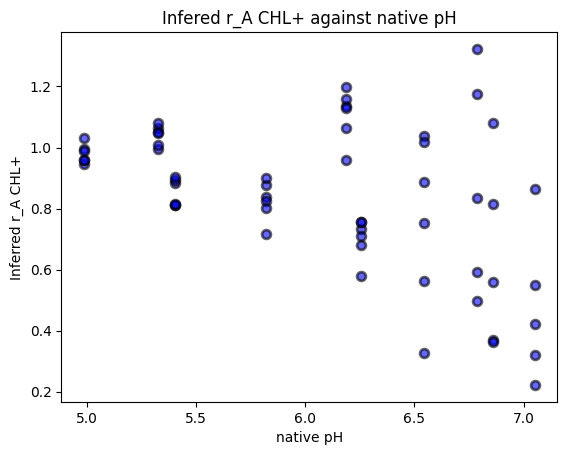

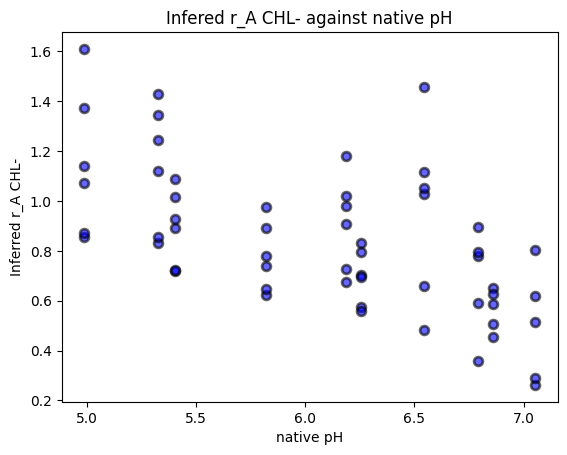

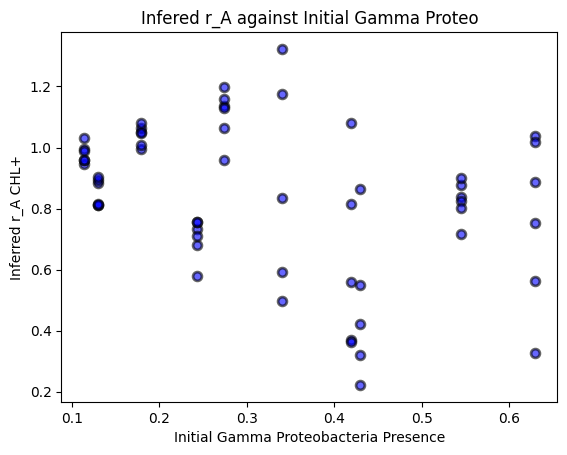

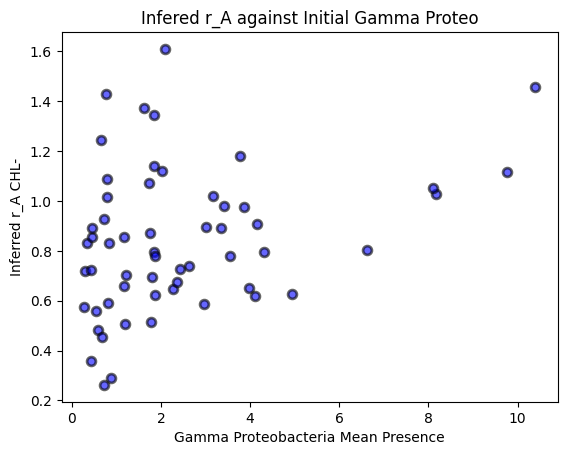

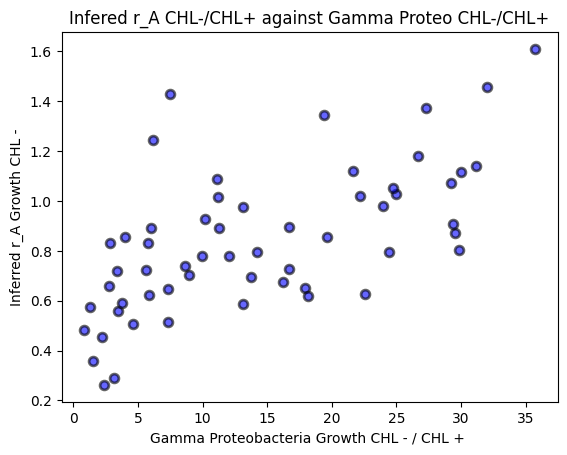

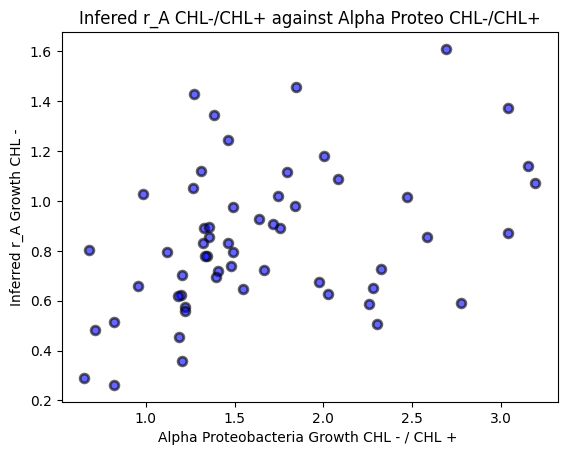

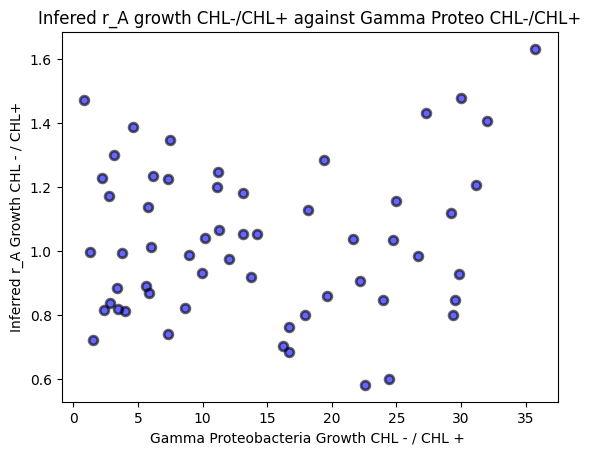

In [130]:
native = [4.987, 5.324, 5.405, 5.822, 6.186, 6.255, 6.545, 6.789, 6.86,  7.052]
thres = 2

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(pH_matrix[nat, pert], native[nat], color = 'Black', s=30, alpha = 0.8)
            plt.xlabel('perturbed pH')
            plt.ylabel('native pH')
                
plt.show()
for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(native[nat], param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('native pH')
            plt.ylabel('Inferred r_A CHL+')
            plt.title('Infered r_A CHL+ against native pH')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(native[nat], param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('native pH')
            plt.ylabel('Inferred r_A CHL-')
            plt.title('Infered r_A CHL- against native pH')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter(group_1_T0[nat, pert] + group_3_T0[nat, pert], param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Initial Gamma Proteobacteria Presence')
            plt.ylabel('Inferred r_A CHL+')
            plt.title('Infered r_A against Initial Gamma Proteo')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter((group_1_T0[nat, pert] + group_3_T0[nat, pert] + group_1_T9[nat, pert] + group_3_T9[nat, pert])/2, param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Gamma Proteobacteria Mean Presence')
            plt.ylabel('Inferred r_A CHL-')
            plt.title('Infered r_A against Initial Gamma Proteo')
plt.show()

# for nat in range(10):
#     for pert in range(2,8):
#         if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
#             plt.scatter((group_2_T0[nat, pert] + group_2_T9[nat, pert])/2, param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
#             plt.xlabel('Alpha Proteobacteria Mean Presence')
#             plt.ylabel('Inferred x0r_A CHL-')
#             plt.title('Infered r_Ax0 against Initial Gamma Proteo')
# plt.show()

         
for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter((group_1_T9[nat, pert] + group_3_T9[nat, pert])/(group_1_T0[nat, pert] + group_3_T0[nat, pert]), param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Gamma Proteobacteria Growth CHL - / CHL + ')
            plt.ylabel('Inferred r_A Growth CHL -')
            plt.title('Infered r_A CHL-/CHL+ against Gamma Proteo CHL-/CHL+')
plt.show()

for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter((group_2_T9[nat, pert])/(group_2_T0[nat, pert]), param_values[nat, pert, 1], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Alpha Proteobacteria Growth CHL - / CHL + ')
            plt.ylabel('Inferred r_A Growth CHL -')
            plt.title('Infered r_A CHL-/CHL+ against Alpha Proteo CHL-/CHL+')
plt.show()


for nat in range(10):
    for pert in range(2,8):
        if np.abs(pH_matrix[nat, pert] - native[nat]) < thres:
            plt.scatter((group_1_T9[nat, pert] + group_3_T9[nat, pert])/(group_1_T0[nat, pert] + group_3_T0[nat, pert]), param_values[nat, pert, 1]/param_values[nat, pert, 0], color = 'Blue', linewidths = 2, alpha = 0.6, s = 40, edgecolor='Black')
            plt.xlabel('Gamma Proteobacteria Growth CHL - / CHL + ')
            plt.ylabel('Inferred r_A Growth CHL - / CHL+')
            plt.title('Infered r_A growth CHL-/CHL+ against Gamma Proteo CHL-/CHL+')
plt.show()

### Make a nice small figure with some dynamics

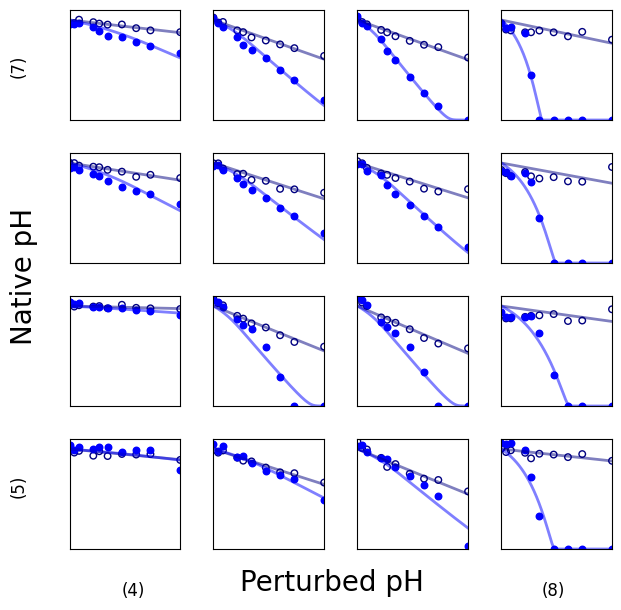

In [124]:
import tqdm.notebook as tqdm
fig, axs = plt.subplots(4, 4, figsize=(7, 7))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
from mgsa.modeling import simulate



t_data = np.linspace(0, 19, 20)
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 
         'Soil15', 'Soil16', 'Soil17']

A_0 = 2
K_A = 0.05
K_C = 0.05
dt = 0.05
T = 9
x_0 = 0.1
gamma = 0.3

N = int(T/dt)

indx = [0, 4, 8, 20, 25, 32, 44, 56, 68, 93]
indices = [int(int(9/dt-1)*x/max(indx)) for x in indx]
indices = np.array(indices)
t_scatter = [9*x/93 for x in indx]

param_values = np.zeros((10,11,2))

native_range = [2, 3, 6, 8]
pert_range = [0, 6, 8, 10]

for nat_idx, native in enumerate(native_range): 
    for pert_idx, pert in enumerate(pert_range):  
        
        C_0 = c0[native, pert]

        sample = samples_from_soils(soils[native])[pert]
        
        function = get_function(sample, drug = 'CHL')
        A_data_drug = np.zeros(10)
        for i in range(3):
            A_data_drug += function[i]
        A_data_drug = A_data_drug/3
        y_data_drug = np.concatenate([A_data_drug])
        
        function = get_function(sample)
        A_data = np.zeros(10)
        for i in range(3):
            A_data += function[i]
        A_data = A_data/3
        y_data = np.concatenate([A_data])
        
        
        def model_drug(t, r_A):

            y0 = np.array([x_0, A_0, 0])
            params = [0, r_A, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        
        initial_guess = [0.1]
        bounds = ([0.00001], [100])
        
        popt, pcov = curve_fit(model_drug, t_data, y_data_drug, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][0] = popt[0]

        y0 = np.array([x_0, A_0, 0])
        params = [0, popt[0],  K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[nat_idx, pert_idx]
        ax.plot(t, A, color='navy', alpha=0.5, linewidth=2)
        ax.scatter(t_scatter, A_data_drug, color='navy', s=22, facecolors = 'none')
        
        def model(t, r_A):

            y0 = np.array([x_0, A_0, C_0])
            params = [gamma, r_A, K_A, K_C]
            _, A, _ = simulate(RHS, y0, params, dt, T)
            A_out = A[indices]
            return np.concatenate([A_out])
        
        initial_guess = [0.1]
            
        bounds = ([0.001], [100])
        
        popt, pcov = curve_fit(model, t_data, A_data, 
                              p0=initial_guess, 
                              bounds=bounds,
                              maxfev=100000)
        
        param_values[native, pert][1] = popt[0]

        y0 = np.array([x_0, A_0, C_0])
        params = [gamma, popt[0], K_A, K_C]
        x, A, C = simulate(RHS, y0, params, dt, T)

        t = np.linspace(0, 9, N)
        
        ax = axs[nat_idx, pert_idx]
        ax.plot(t, A, color='Blue', alpha=0.5, linewidth=2)
        ax.scatter(t_scatter, A_data, color='Blue', s=22)
        
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 2.2)
        
        ax.set_xticks([])
        ax.set_yticks([])
        
fig.text(0.04, 0.2, '(5)', va='center', rotation='vertical', fontsize=12)
fig.text(0.04, 0.8, '(7)', va='center', rotation='vertical', fontsize=12)

fig.text(0.04, 0.5, 'Native pH', va='center', rotation='vertical', fontsize=20)

fig.text(0.2, 0.05, '(4)', va='center',  fontsize=12)
fig.text(0.8, 0.05, '(8)', va='center', fontsize=12)

fig.text(0.5, 0.05, 'Perturbed pH', ha='center', fontsize=20)
plt.show()